### Hyper-parameters

In [10]:
import os
import pandas as pd
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import ast

In [ ]:
actor_num = 0 # LDA 진행하고자 하는 actor 번호; 0~4
topic_num_ = 3 # topic 개수

In [4]:
df = pd.read_csv(f'../clustering/results_clustering/ActorClustering_kmeans_kure_128_k5_bigram.csv', encoding='utf-8-sig')

print(len(df))
df.head()

58314


,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프..."
1,1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,"['하지불안 증후군', '다리', '감각', '느끼다', '해소', '위하다', '...",[ 0.02329755 0.33748412 5.701536 10.034008...,2,"['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '..."
2,2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['트다', '살', '크림', '종류', '많다', '알아보다', '종류', '다...",[4.2346669e-03 1.8436287e-02 9.1599712e+00 8.8...,4,"['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ..."
3,3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,"['셀프', '산후', '조리', '시작', '완', '산후', '도우미', '부르...",[0.02605256 0.21050377 7.150107 9.429928 1...,2,"['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산..."
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다..."


In [5]:
df['tokenized'] = df['bigram']
df.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized
0,0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,"['돌', '지나다', '돌', '전', '집', '사다', '프뢰벨', '영아',...",[ 8.4111039e-03 -2.8329432e-02 1.0804157e+01 ...,1,"['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프...","['돌_지나다', '지나다_돌', '돌_전', '전_집', '집_사다', '사다_프..."
1,1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,"['하지불안 증후군', '다리', '감각', '느끼다', '해소', '위하다', '...",[ 0.02329755 0.33748412 5.701536 10.034008...,2,"['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '...","['하지불안 증후군_다리', '다리_감각', '감각_느끼다', '느끼다_해소', '..."
2,2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['트다', '살', '크림', '종류', '많다', '알아보다', '종류', '다...",[4.2346669e-03 1.8436287e-02 9.1599712e+00 8.8...,4,"['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ...","['트다_살', '살_크림', '크림_종류', '종류_많다', '많다_알아보다', ..."
3,3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,"['셀프', '산후', '조리', '시작', '완', '산후', '도우미', '부르...",[0.02605256 0.21050377 7.150107 9.429928 1...,2,"['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산...","['셀프_산후', '산후_조리', '조리_시작', '시작_완', '완_산후', '산..."
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...","['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다..."


# ◆ 1. LDA를 위한 데이터 전처리
* 1.1. 전체 단어의 사전 만들고 각 문서에 매칭하기
    > 단어들이 문서에 얼마나 위치해 있는지 분포를 파악해야하기 때문에 분석할 전체 데이터 대상으로
    사용된 단어의 사전을 생성해야한다,


In [6]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary

### 1.1 전체 단어의 사전 만들고 각 문서에 매칭하기

In [7]:
# cluster 0
df_cluster0 = df[df['cluster'] == actor_num]
print(len(df_cluster0))
df_cluster0.head()

18343


,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...","['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다..."
8,8,네이버카페_맘이베베,육아질문방,원래 둘째 임신이 더 힘든거에요,찻째 때는 임신 증상 하나도 없었는데 둘째는 입덧 먹덧 허리통증 환도통증 미칠거같네...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['찻째', '임신', '증상', '입덧', '먹다', '덧', '허리', '통증'...",[5.0695366e-03 6.1790273e-02 8.5887194e+00 1.0...,0,"['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...","['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '..."
12,12,네이버카페_맘이베베,육아질문방,주차인데 선홍색 피비침 화유일까요,월에도 화유했는데 너무 불안하네요 아침에 눈떠서 소변보는데 피가살짝 비쳐서 일단 출...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['화유', '불안', '아침', '눈뜨다', '소변', '피', '비치다', '출...",[9.5095383e-03 8.8404916e-02 8.2806053e+00 1.1...,0,"['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...","['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',..."
15,15,네이버카페_맘이베베,육아질문방,임당은 몇주에가서 검사하나요,지금 주인데 주 일에 정밀초음파보려가요 임당은 몇주부터 몇주까지 검사하려가야하나요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주', '정밀', '초음파', '임', '당', '검사']",[ 0.01279403 0.05238488 8.926166 10.237827...,0,"['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']","['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']"
24,24,네이버카페_맘이베베,육아질문방,인기없는 원장님은 이유가 있네요,간밤에 복통와 출혈로 글썼던 경산모입니다 제가 딱 년전 작년 월에 미즈 에서 다발성...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['간밤', '복통', '오다', '출혈', '글', '쓰다', '경', '산모',...",[ 0.01203783 0.06573231 8.56908 10.456011...,0,"['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...","['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰..."


In [11]:
# 1. 문자열을 실제 리스트로 변환해주는 함수
def parse_tokens(text):
    if isinstance(text, str):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            # 만약 "단어1 단어2" 형태의 단순 띄어쓰기 문자열이라면 split() 적용
            return text.split()
    return text

# 2. 'tokenized' 컬럼에 함수 적용 후 리스트로 변환
all_documents = df_cluster0['tokenized'].apply(parse_tokens).tolist()

# 3. 사전(Dictionary) 생성
dictionary = Dictionary(all_documents)

# 결과 확인
print(f"단어장 생성 완료! 총 단어 개수: {len(dictionary)}")
dictionary.token2id  # 필요 시 주석 해제하여 확인

단어장 생성 완료! 총 단어 개수: 227522


{'견디다_나아지다': 0,
 '공복_먹다': 1,
 '기준_주관': 2,
 '끼_끼': 3,
 '끼_먹다': 4,
 '내일_주': 5,
 '냄새_덧': 6,
 '냄새_체하다': 7,
 '다르다_음식': 8,
 '덧_냄새': 9,
 '덧_증상': 10,
 '덧_체': 11,
 '먹다_모르다': 12,
 '먹다_양': 13,
 '먹다_직후': 14,
 '먹다_토덧': 15,
 '먹다_하루': 16,
 '모르다_심하다': 17,
 '속_덧': 18,
 '심하다_기준': 19,
 '심하다_냄새': 20,
 '아침_공복': 21,
 '약_처방': 22,
 '양_줄다': 23,
 '여야_입덧': 24,
 '음식_먹다': 25,
 '입덧_다르다': 26,
 '입덧_약': 27,
 '정도_여야': 28,
 '주_견디다': 29,
 '주관_내일': 30,
 '줄다_먹다': 31,
 '증상_아침': 32,
 '직후_심하다': 33,
 '참다_정도': 34,
 '처방_먹다': 35,
 '체_덧': 36,
 '체하다_헛트름': 37,
 '토덧_참다': 38,
 '하루_끼': 39,
 '헛트름_속': 40,
 '눈물_둘째': 41,
 '덧_허리': 42,
 '둘째_힘들다': 43,
 '먹다_덧': 44,
 '미치다_허리': 45,
 '서다_아프다': 46,
 '아프다_눈물': 47,
 '아프다_서다': 48,
 '옆_아프다': 49,
 '임신_증상': 50,
 '입덧_먹다': 51,
 '증상_입덧': 52,
 '찻째_임신': 53,
 '통증_미치다': 54,
 '통증_옆': 55,
 '통증_환도': 56,
 '허리_통증': 57,
 '허리_환도': 58,
 '환도_통증': 59,
 '눈뜨다_소변': 60,
 '배_아프다': 61,
 '불안_아침': 62,
 '비치다_출근': 63,
 '소변_피': 64,
 '아침_눈뜨다': 65,
 '아프다_불안': 66,
 '출근_배': 67,
 '출근_출근': 68,
 '피_비치다': 69,
 '화유_불안': 70,
 '당_검사': 71,
 '

In [12]:
corpus = []
for doc in all_documents:
    corpus.append(dictionary.doc2bow(doc))
    
corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 1),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1)],
 [(41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 1),
  (57, 1),
  (58, 1),
  (59, 2)],
 [(60, 1),
  (61, 1),
  (62, 1),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 1)],
 [(71, 1), (72, 1), (73, 1), (74, 1), (75, 1)],
 [(76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 2),
  (81, 1),
  (82, 1),
  (83, 1),
  (84, 3),
  (85, 1),
  (86, 1),
  (87, 1),
  (88, 1),
  (89, 1),
  (90, 1),
  (91, 1),
  

# ◆ 2. LDA모델 만들기
* 2.1 LDA 기본 모델 만들기
* 2.2 LDA 토픽개수 선정
* 2.3 선정한 토픽 개수로 Action 넘버 매칭

### 2.1 LDA 기본 모델 만들기

In [9]:
# topic_num = 4 # 3 
# ldamodel = gensim.models.ldamodel.LdaModel(corpus,
#                                            num_topics= topic_num,
#                                            id2word= dictionary,
#                                            passes= 20,
#                                            iterations= 50,
#                                            random_state= 42)

In [10]:
# ldamodel.print_topics(num_words= 10)

In [11]:
# for i in range(int(len(corpus)/100)):
#     print(ldamodel.get_document_topics(corpus[i]))

### 2.2 LDA 토픽 수 선정
* cohearence & perplexcity

In [13]:
from gensim.models import CoherenceModel # coherence 모델 라이브러리
import matplotlib.pyplot as plt # 그래프 그리기
import numpy as np

> 2.2.1 Perplexity 그래프 만들기

In [14]:
perplexity_values = []

for i in range(2, 10):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    perplexity_v = np.exp(-ldamodel.log_perplexity(corpus))
    perplexity_values.append(perplexity_v)

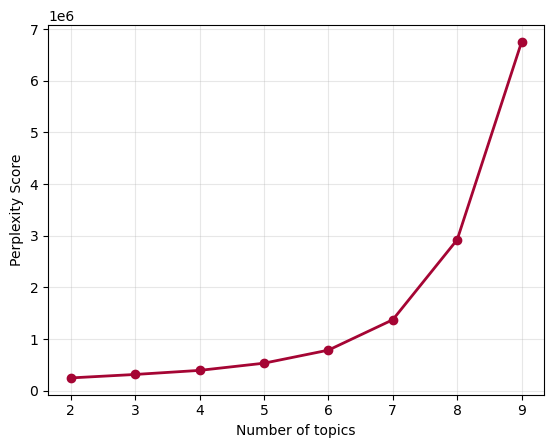

In [15]:
x = range(2, 10)

plt.plot(
    x,
    perplexity_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Perplexity Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'./results/LDA_Actor{actor_num}_action_cluster_perplexity_plot.png', dpi=300, transparent=True)
plt.show()

In [16]:
# perplexity 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, perplexity_values]).T
result0.columns = ['n_cluster', 'perplexity_values']
result0.to_excel(f'./results/LDA_Actor{actor_num}_action_cluster_perplexity.xlsx', index=False)

> 2.2.1 Coherence 그래프 만들기

In [17]:
coherence_values = []
top_n = 3

for i in tqdm(range(2,10)):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    coherence_model = CoherenceModel(model= ldamodel,
                                 texts= all_documents,
                                 dictionary= dictionary,
                                 topn= top_n)
    
    coherence_score = coherence_model.get_coherence()
    coherence_values.append(coherence_score)

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [01:41<00:00, 12.66s/it]


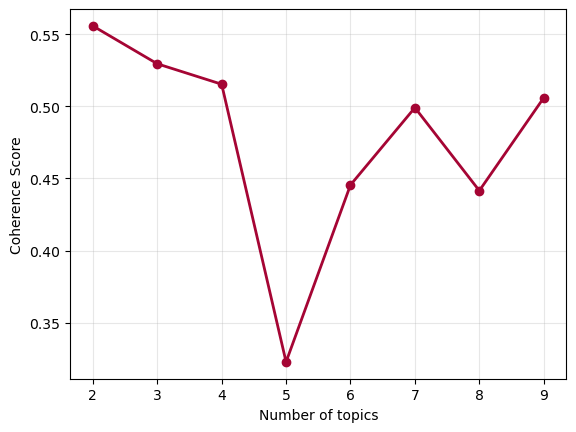

In [18]:
x = range(2, 10)

plt.plot(
    x,
    coherence_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Coherence Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'./results/LDA_Actor{actor_num}_action_cluster_coherance_plot.png', dpi=300, transparent=True)
plt.show()

In [19]:
# Coherance 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, coherence_values]).T
result0.columns = ['n_cluster', 'coherence_values']
result0.to_excel(f'./results/LDA_Actor{actor_num}_action_cluster_coherence.xlsx', index=False)

### 2.3 선정한 토픽 개수로 Action 넘버 매칭

In [20]:
topic_num = topic_num_ # 3

ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                           num_topics= topic_num,
                                           id2word= dictionary,
                                           passes= 20,
                                           iterations= 50,
                                           random_state= 42)

In [21]:
ldamodel.get_document_topics(corpus)[2]

[(0, 0.029238228), (1, 0.02930836), (2, 0.94145346)]

In [22]:
action_align = []

for doc in tqdm(ldamodel.get_document_topics(corpus)):
    label = []
    value = []
    
    for score in doc:
        label.append(score[0])
        value.append(score[1])
        
    max_index = np.argmax(value)
    action_n = label[max_index]
    action_align.append(action_n)
    

100%|██████████| 18343/18343 [00:02<00:00, 8271.27it/s]


In [23]:
df_cluster0['action_cluster'] = action_align
df_cluster0.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized,action_cluster
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...","['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...",2
8,8,네이버카페_맘이베베,육아질문방,원래 둘째 임신이 더 힘든거에요,찻째 때는 임신 증상 하나도 없었는데 둘째는 입덧 먹덧 허리통증 환도통증 미칠거같네...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['찻째', '임신', '증상', '입덧', '먹다', '덧', '허리', '통증'...",[5.0695366e-03 6.1790273e-02 8.5887194e+00 1.0...,0,"['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...","['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...",2
12,12,네이버카페_맘이베베,육아질문방,주차인데 선홍색 피비침 화유일까요,월에도 화유했는데 너무 불안하네요 아침에 눈떠서 소변보는데 피가살짝 비쳐서 일단 출...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['화유', '불안', '아침', '눈뜨다', '소변', '피', '비치다', '출...",[9.5095383e-03 8.8404916e-02 8.2806053e+00 1.1...,0,"['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...","['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...",2
15,15,네이버카페_맘이베베,육아질문방,임당은 몇주에가서 검사하나요,지금 주인데 주 일에 정밀초음파보려가요 임당은 몇주부터 몇주까지 검사하려가야하나요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주', '정밀', '초음파', '임', '당', '검사']",[ 0.01279403 0.05238488 8.926166 10.237827...,0,"['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']","['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']",0
24,24,네이버카페_맘이베베,육아질문방,인기없는 원장님은 이유가 있네요,간밤에 복통와 출혈로 글썼던 경산모입니다 제가 딱 년전 작년 월에 미즈 에서 다발성...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['간밤', '복통', '오다', '출혈', '글', '쓰다', '경', '산모',...",[ 0.01203783 0.06573231 8.56908 10.456011...,0,"['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...","['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...",0


In [24]:
df_cluster0['action_cluster'].value_counts()

action_cluster
2    8334
0    5214
1    4795
Name: count, dtype: int64

# ◆ 3. LDA 시각화 (LDAvis)


In [24]:
# !pip install pyLDAvis

In [25]:
#경고무시
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#LDA 시각화 라이브러리
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [26]:
prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary)
# pyLDAvis.save_html(prepared_data, f'{output_path}/ldavis_Actor_{actor_num}.html')
pyLDAvis.save_html(prepared_data, f'./results/LDA_Actor{actor_num}_ldavis.html')
# pyLDAvis.display(prepared_data)

In [27]:
pyLDAvis.display(prepared_data)

# ◆ 4. LDA 분석을 위한 후작업
* LDAvis와 LDA모델의 토픽 넘버 매칭
* LDAvis 결과와 LDA모델의 결과를 보고 직접 매칭해야한다.

In [28]:
topics = ldamodel.show_topics(num_topics= -1, # - 1 은 다 가져오라는것
                              formatted= True,
                              )

for topic_id, topic_desc in topics :
    print(f"Topic ID : {topic_id}, Description : {topic_desc}")

Topic ID : 0, Description : 0.003*"임_당" + 0.002*"진통_오다" + 0.002*"당_검사" + 0.002*"유도_분만" + 0.002*"자연_분만" + 0.001*"영유아_검진" + 0.001*"기형아_검사" + 0.001*"대학_병원" + 0.001*"임신_당뇨" + 0.001*"양수_터지다"
Topic ID : 1, Description : 0.003*"태아_보험" + 0.003*"조리_원" + 0.002*"약_먹다" + 0.002*"예방_접종" + 0.001*"해열제_먹이다" + 0.001*"잠_자다" + 0.001*"감기_걸리다" + 0.001*"약_먹이다" + 0.001*"먹다_먹다" + 0.001*"입덧_약"
Topic ID : 2, Description : 0.003*"아기_집" + 0.002*"배_뭉치다" + 0.002*"배_아프다" + 0.002*"약_먹다" + 0.001*"생리_예정일" + 0.001*"피_검사" + 0.001*"출산_후" + 0.001*"심장_소리" + 0.001*"먹다_먹다" + 0.001*"배_나오다"


In [34]:
# 모델 LDAvis
# lda   ldavis
# 0     3
# 1     1
# 2     2
lda_ldavis_map = {0:'2',
                  1:'3',
                  2:'1'
                  }

In [36]:
new_action_topic = []

for i in df_cluster0['action_cluster'] :
    n = lda_ldavis_map[i]
    
    # if i == 0 :
    #     n = 3
    # elif i == 1 : 
    #     n = 1
    # elif i == 2 :
    #     n = 2
    # else : 
    #     n = 1
    new_action_topic.append(n)

In [37]:
df_cluster0['action_cluster'] = new_action_topic
df_cluster0.head()

,Unnamed: 0,출처,키워드,제목,내용,작성일,링크,token,vector,cluster,bigram,tokenized,action_cluster
4,4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['입덧', '다르다', '음식', '먹다', '직후', '심하다', '냄새', '...",[2.0861698e-03 7.1943946e-02 8.5836906e+00 1.0...,0,"['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...","['입덧_다르다', '다르다_음식', '음식_먹다', '먹다_직후', '직후_심하다...",1
8,8,네이버카페_맘이베베,육아질문방,원래 둘째 임신이 더 힘든거에요,찻째 때는 임신 증상 하나도 없었는데 둘째는 입덧 먹덧 허리통증 환도통증 미칠거같네...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['찻째', '임신', '증상', '입덧', '먹다', '덧', '허리', '통증'...",[5.0695366e-03 6.1790273e-02 8.5887194e+00 1.0...,0,"['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...","['찻째_임신', '임신_증상', '증상_입덧', '입덧_먹다', '먹다_덧', '...",1
12,12,네이버카페_맘이베베,육아질문방,주차인데 선홍색 피비침 화유일까요,월에도 화유했는데 너무 불안하네요 아침에 눈떠서 소변보는데 피가살짝 비쳐서 일단 출...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['화유', '불안', '아침', '눈뜨다', '소변', '피', '비치다', '출...",[9.5095383e-03 8.8404916e-02 8.2806053e+00 1.1...,0,"['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...","['화유_불안', '불안_아침', '아침_눈뜨다', '눈뜨다_소변', '소변_피',...",1
15,15,네이버카페_맘이베베,육아질문방,임당은 몇주에가서 검사하나요,지금 주인데 주 일에 정밀초음파보려가요 임당은 몇주부터 몇주까지 검사하려가야하나요,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['주', '정밀', '초음파', '임', '당', '검사']",[ 0.01279403 0.05238488 8.926166 10.237827...,0,"['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']","['주_정밀', '정밀_초음파', '초음파_임', '임_당', '당_검사']",2
24,24,네이버카페_맘이베베,육아질문방,인기없는 원장님은 이유가 있네요,간밤에 복통와 출혈로 글썼던 경산모입니다 제가 딱 년전 작년 월에 미즈 에서 다발성...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,"['간밤', '복통', '오다', '출혈', '글', '쓰다', '경', '산모',...",[ 0.01203783 0.06573231 8.56908 10.456011...,0,"['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...","['간밤_복통', '복통_오다', '오다_출혈', '출혈_글', '글_쓰다', '쓰...",2


In [40]:
df_cluster0 = df_cluster0[['출처', '키워드', '제목', '내용', '작성일', '링크', 'tokenized', 'cluster', 'action_cluster']]

In [41]:
# csv 저장
df_cluster0.to_csv(f'./results/LDA_Actor{actor_num}_action_cluster.csv', encoding='utf-8-sig')

In [42]:
df_cluster0['action_cluster'].value_counts()

action_cluster
1    8334
2    5214
3    4795
Name: count, dtype: int64